<a href="https://colab.research.google.com/github/alexpanayi474/DSC511-MovieLens-Project/blob/main/DSC_511_MovieLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# give access to google colab to have access to your google drive, in order to be able to read the datasets
from google.colab import drive
drive.mount('/content/gdrive')
google_drive_path = "/content/gdrive/MyDrive/Colab Notebooks/Data/DSC_511_PROJECT/"

Mounted at /content/gdrive


In [11]:
#  Spark Core
from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import *
from pyspark.sql.types import *

# EDA / Visualization (Pandas + Plotting)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  ML: Feature Engineering
from pyspark.ml import Pipeline
from pyspark.ml.feature import *

#  ML: Regression Models
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor

#  ML: Evaluation
from pyspark.ml.evaluation import RegressionEvaluator

#  ML: Hyperparameter Tuning
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

#  Recommendation System (ALS)
from pyspark.ml.recommendation import ALS


# create a spark session
spark = SparkSession.builder.appName("DSC_511_PROJECT").master("local[*]") .getOrCreate()

In [3]:
# 2. Data Ingestion
# Load the MovieLens CSV files into Spark DataFrames.
# Spark infers the schema automatically (inferSchema=True),
# mapping columns to their appropriate types (int, double, string).
ratings_df = spark.read.csv(google_drive_path + 'ratings.csv', header=True, inferSchema=True)
ratings_df.printSchema()

movies_df = spark.read.csv(google_drive_path + 'movies.csv', header=True, inferSchema=True)
movies_df.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



In [13]:
# ── Persist DataFrames in memory
ratings_df.persist()
movies_df.persist()

DataFrame[movieId: int, title: string, genres: string]

In [4]:
ratings_df.count() #rows in ratings_df

33832162

In [5]:
movies_df.count() #rows in movies_df

86537

In [6]:
#overview of the data
ratings_df.show(5)
movies_df.show(5)

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|      1|   4.0|1225734739|
|     1|    110|   4.0|1225865086|
|     1|    158|   4.0|1225733503|
|     1|    260|   4.5|1225735204|
|     1|    356|   5.0|1225735119|
+------+-------+------+----------+
only showing top 5 rows
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [9]:
#checking for NAs
from pyspark.sql.functions import col, sum as spark_sum, count
print("NULLs in ratings_df")
ratings_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in ratings_df.columns]).show()

print("NULLs in movies_df")
movies_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in movies_df.columns]).show()

NULLs in ratings_df
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

NULLs in movies_df
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+



In [12]:
# checking for duplicates
print("Duplicates in ratings_df:", ratings_df.count() - ratings_df.dropDuplicates().count())
print("Duplicates in movies_df:", movies_df.count() - movies_df.dropDuplicates().count())

Duplicates in ratings_df: 0
Duplicates in movies_df: 0


In [14]:
#from pyspark.sql.functions import col, from_unixtime, to_timestamp
# converting Unix timestamp to readable datetime format
ratings_clean = ratings_df.withColumn("ts", to_timestamp(from_unixtime(col("timestamp"))))

In [15]:
# merging the dataframes
movies_ratings_merged = ratings_clean.join(movies_df, on="movieId", how="inner")
movies_ratings_merged.select("userId","movieId","rating","ts","title","genres").show(5, truncate=False)

+------+-------+------+-------------------+-----------------------------------------+-------------------------------------------+
|userId|movieId|rating|ts                 |title                                    |genres                                     |
+------+-------+------+-------------------+-----------------------------------------+-------------------------------------------+
|1     |1      |4.0   |2008-11-03 17:52:19|Toy Story (1995)                         |Adventure|Animation|Children|Comedy|Fantasy|
|1     |110    |4.0   |2008-11-05 06:04:46|Braveheart (1995)                        |Action|Drama|War                           |
|1     |158    |4.0   |2008-11-03 17:31:43|Casper (1995)                            |Adventure|Children                         |
|1     |260    |4.5   |2008-11-03 18:00:04|Star Wars: Episode IV - A New Hope (1977)|Action|Adventure|Sci-Fi                    |
|1     |356    |5.0   |2008-11-03 17:58:39|Forrest Gump (1994)                      |Comed

In [36]:
#  Find the actual date range of ratings in the dataset
ratings_clean.select(min("ts").alias("oldest_rating"),max("ts").alias("newest_rating")).show(truncate=False)

+-------------------+-------------------+
|oldest_rating      |newest_rating      |
+-------------------+-------------------+
|1995-01-09 11:46:44|2023-07-20 08:53:33|
+-------------------+-------------------+



In [16]:
# basic statistics for the rating column
movies_ratings_merged.select("rating").describe().show()

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|          33832162|
|   mean|  3.54254040873888|
| stddev|1.0639586178664766|
|    min|               0.5|
|    max|               5.0|
+-------+------------------+



In [18]:
# unique users, movies and total records in the joined dataframe
print("Total ratings:", movies_ratings_merged.count())
print("Unique users:", movies_ratings_merged.select("userId").distinct().count())
print("Unique movies:", movies_ratings_merged.select("movieId").distinct().count())
# movies_df contains 86,537 movies but the joined df only has 83,239 unique movies, due to the fact that some movies exist in movies_df but have no ratings in ratings_df.

Total ratings: 33832162
Unique users: 330975
Unique movies: 83239


In [20]:
# rating value distribution ,frequency of each rating
movies_ratings_merged.groupBy("rating").count().orderBy("rating").show()

+------+-------+
|rating|  count|
+------+-------+
|   0.5| 566306|
|   1.0|1013645|
|   1.5| 562409|
|   2.0|2146492|
|   2.5|1760733|
|   3.0|6400664|
|   3.5|4465001|
|   4.0|8835955|
|   4.5|3123055|
|   5.0|4957902|
+------+-------+



# **EDA**
## EDA Part 1: Movies Released Per Year

We begin by extracting the **release year** from each movie title using a regular expression,
since the year is embedded in the title string (e.g. *"Toy Story (1995)"*).

This analysis is performed on the **full `movies_df`** dataset (86,537 movies), which includes
movies that were never rated on MovieLens. This gives a more accurate picture of movie
production over time, compared to using only the joined DataFrame which would exclude ~3,300
unrated movies.

> **Note:** This chart reflects movies *catalogued on MovieLens*, not the entire global film
> production — so it carries a bias toward popular and English-language films.

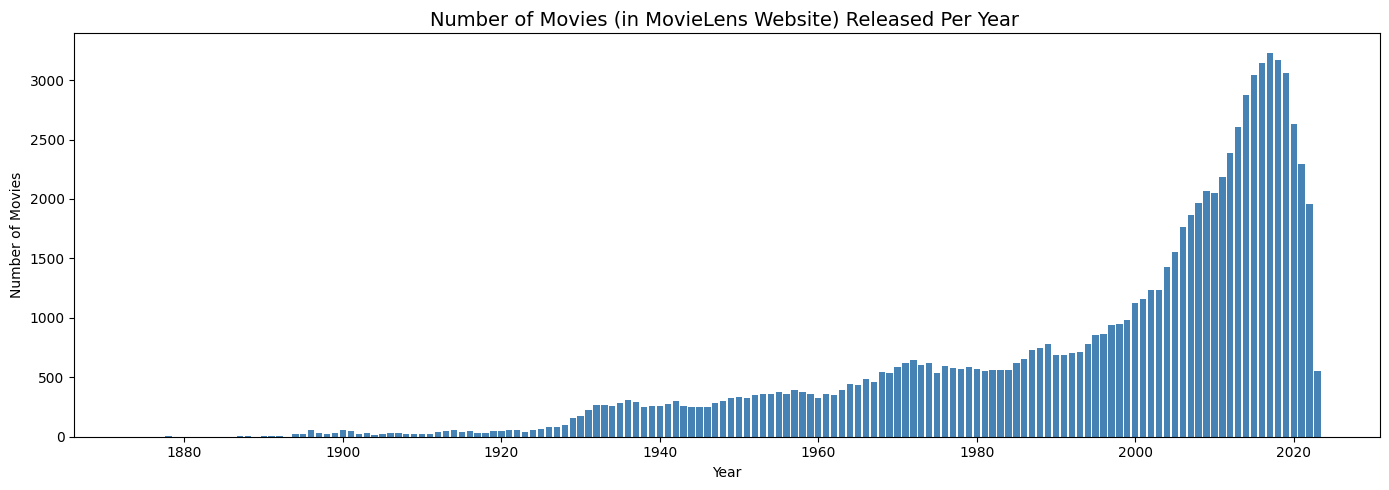

In [27]:
# Extract year from title string using regex, then groupBy year
movies_with_year = movies_df.withColumn("release_year",regexp_extract(col("title"), r"\((\d{4})\)", 1))

movies_per_year = (movies_with_year
    .filter(col("release_year") != "")     # remove empty matches BEFORE casting
    .withColumn("release_year", col("release_year").cast("int")) # regexp_extract always returns a string (e.g. "1995"), .cast() converts a column from one data type to another
    .groupBy("release_year").agg(count("movieId").alias("num_movies")).orderBy("release_year").toPandas()
)

plt.figure(figsize=(14, 5))
plt.bar(movies_per_year["release_year"], movies_per_year["num_movies"], color="steelblue", width=0.8)
plt.title("Number of Movies (in MovieLens Website) Released Per Year ", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### Observations

- **Pre-1940s**: Very few titles — the film industry was still in its infancy.
- **1940s–1970s**: Slow but steady growth as cinema became a mainstream entertainment medium.
- **1980s–2000s**: Rapid acceleration driven by the **home video revolution** (VHS/DVD),
  which made cataloguing older and new films more viable.
- **Peak around 2015–2018**: The **streaming era** (Netflix, Amazon Prime, Disney+) triggered
  a global surge in film and series production.
- **Drop after 2020**: Attributable to **COVID-19** production shutdowns in 2020–2021,
  combined with the dataset's collection cutoff date.
- **Included but unrated**: The ~3,300 movies present in `movies_df` but absent from
  `ratings_df` are still counted here — they are valid productions simply never reviewed
  by MovieLens users.

## Part 2: MovieLens Platform Popularity Over Time
To understand how the **MovieLens platform grew over time**, we analyze the total number
of ratings submitted by users in each **6-month period** from 1997 (platform launch) to 2023.

We use the `ratings_clean` DataFrame which already has the `ts` column — a proper Spark
timestamp converted from the raw Unix epoch integer in `ratings_df`.

### Why 6-month bins?
Monthly bins would produce ~300 bars (too noisy). Yearly bins would hide seasonal patterns.
6-month bins give a clean balance — enough granularity to see trends without clutter.


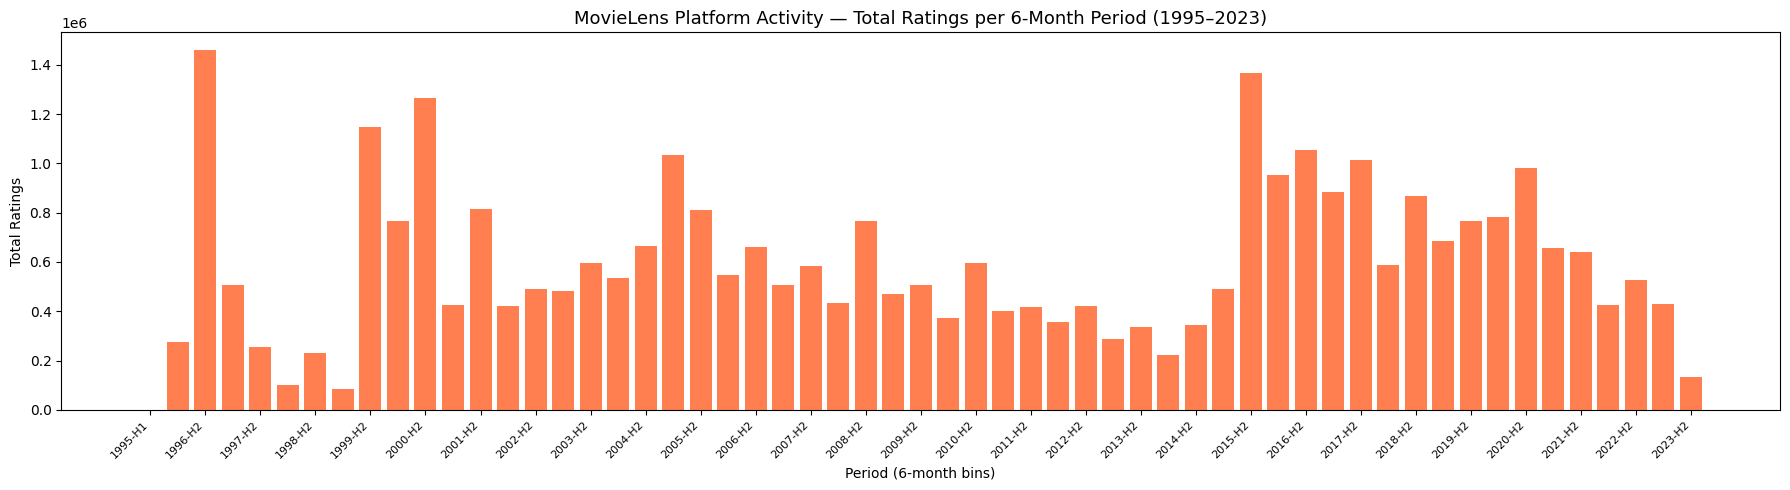

In [38]:
# Count total ratings per 6-month period from 1997 to 2023
# Group by 6-month periods to track platform growth.
from pyspark.sql.functions import year, month, concat_ws, lpad, count, col, when,floor

ratings_timeline = (ratings_clean

    # Step 1: Extract year and month from the timestamp column
    .withColumn("year",  year(col("ts")))
    .withColumn("month", month(col("ts")))

    # floor(month / 6) == 0 → months 1-5 → H1
    # floor(month / 6) != 0 → months 6-12 → H2
    .withColumn("half",
        when(floor(col("month") / 6) == 0, "H1").otherwise("H2")
    )

    # Step 3: Build readable period label e.g. "2005-H1", "2005-H2"
    .withColumn("period_label",
        concat_ws("-", col("year").cast("string"), col("half"))
    )

    # Step 4: Keep only ratings from 1997 (platform launch) to 2023
    #.filter((col("year") >= 1997) & (col("year") <= 2023))

    # Step 5: Group by period and count total ratings in each 6-month bin
    .groupBy("year", "half", "period_label")
    .agg(count("rating").alias("total_ratings"))

    # Step 6: Sort chronologically — H1 before H2 within each year
    .orderBy("year", "half")

    .toPandas()
)

plt.figure(figsize=(18, 5))
plt.bar(range(len(ratings_timeline)), ratings_timeline["total_ratings"], color="coral")
plt.xticks(
    range(0, len(ratings_timeline), 2),       # show every 2nd label to avoid overlap
    ratings_timeline["period_label"].iloc[::2],
    rotation=45, ha="right", fontsize=8
)
plt.title("MovieLens Platform Activity — Total Ratings per 6-Month Period (1995–2023)", fontsize=13)
plt.xlabel("Period (6-month bins)")
plt.ylabel("Total Ratings")
plt.tight_layout()
plt.show()

### Observations

- **1996-H2 (highest peak ~1.45M)**: Surprisingly the most active period — likely a
  large batch import of retrospective ratings when the platform launched, where early
  adopters rated many movies at once.
- **1999-H2 → 2001-H2**: Second surge coinciding with the **DVD boom** and growing
  internet adoption.
- **2005-H1**: Notable peak likely driven by **Netflix's growing popularity** pushing
  users to discover and rate more films.
- **2007–2014 (steady decline)**: Gradual drop as competing platforms
  (IMDb, Rotten Tomatoes) fragmented the user base.
- **2016-H1 (strong resurgence ~1.38M)**: The **streaming era** reignited interest
  in movie rating and discovery tools.
- **2023-H2 (sharp drop)**: Incomplete period — dataset collection cutoff,
  not a real decline in activity.

## Part 3: Top 10 Highest Rated Movies (with num_ratings $\ge$ 1000)

In [44]:
# Aggregate avg rating + rating count per movie
movie_stats = (movies_ratings_merged
    .groupBy("movieId", "title")
    .agg(spark_round(avg("rating"), 3).alias("avg_rating"),count("rating").alias("num_ratings"))
    .filter(col("num_ratings") >= 1000).orderBy(desc("avg_rating")).limit(10))

movie_stats.select("title", "avg_rating", "num_ratings").show(10, truncate=False)

+--------------------------------+----------+-----------+
|title                           |avg_rating|num_ratings|
+--------------------------------+----------+-----------+
|Planet Earth II (2016)          |4.452     |2041       |
|Planet Earth (2006)             |4.448     |3015       |
|Band of Brothers (2001)         |4.424     |2835       |
|Shawshank Redemption, The (1994)|4.417     |122296     |
|Parasite (2019)                 |4.33      |12399      |
|Godfather, The (1972)           |4.327     |75004      |
|Blue Planet II (2017)           |4.313     |1267       |
|Twin Peaks (1989)               |4.303     |1132       |
|Godfather: Part II, The (1974)  |4.27      |47271      |
|Usual Suspects, The (1995)      |4.268     |72893      |
+--------------------------------+----------+-----------+



## Part 4: Top 10 Most Popular Movies - in MovieLens (most rated)

In [45]:
# Top 10 Most Popular Movies — popularity = most ratings received
most_popular = (movies_ratings_merged
    .groupBy("movieId", "title")
    .agg(
        count("rating").alias("num_ratings"),
        spark_round(avg("rating"), 3).alias("avg_rating")
    )
    .orderBy(desc("num_ratings"))
    .limit(10)
)

most_popular.select("title", "num_ratings", "avg_rating").show(10, truncate=False)

+-----------------------------------------------------+-----------+----------+
|title                                                |num_ratings|avg_rating|
+-----------------------------------------------------+-----------+----------+
|Shawshank Redemption, The (1994)                     |122296     |4.417     |
|Forrest Gump (1994)                                  |113581     |4.068     |
|Pulp Fiction (1994)                                  |108756     |4.192     |
|Matrix, The (1999)                                   |107056     |4.161     |
|Silence of the Lambs, The (1991)                     |101802     |4.15      |
|Star Wars: Episode IV - A New Hope (1977)            |97202      |4.092     |
|Fight Club (1999)                                    |86207      |4.236     |
|Schindler's List (1993)                              |84232      |4.242     |
|Jurassic Park (1993)                                 |83026      |3.689     |
|Star Wars: Episode V - The Empire Strikes Back (198

## Part 5: Genre Analysis



=== Distinct Genres (20 total) ===
+----------------------------------+
|genre                             |
+----------------------------------+
| We're Comin' To Get Ya!"" (2014)"|
|Action                            |
|Adventure                         |
|Animation                         |
|Children                          |
|Comedy                            |
|Crime                             |
|Documentary                       |
|Drama                             |
|Fantasy                           |
|Film-Noir                         |
|Horror                            |
|IMAX                              |
|Musical                           |
|Mystery                           |
|Romance                           |
|Sci-Fi                            |
|Thriller                          |
|War                               |
|Western                           |
+----------------------------------+



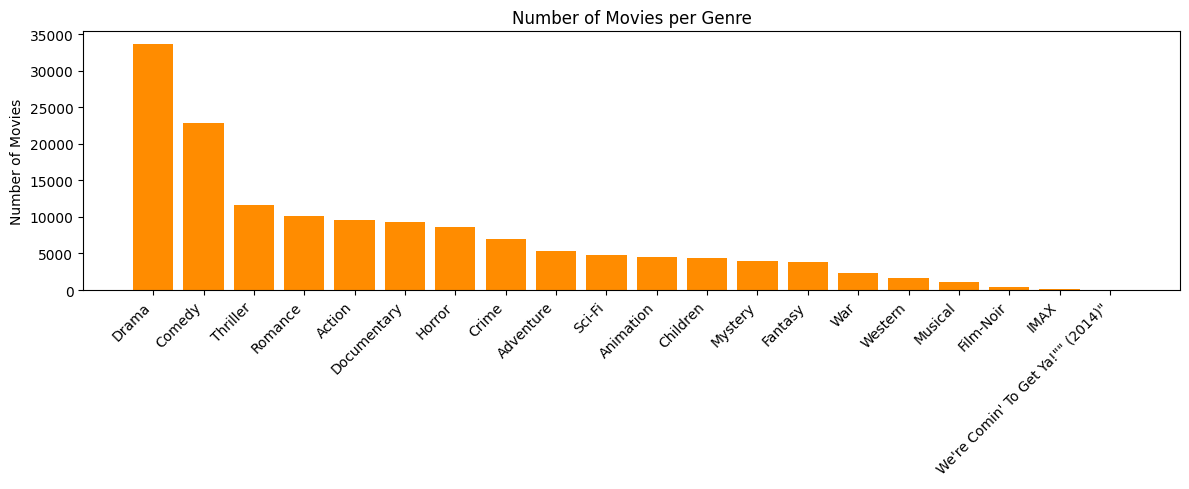

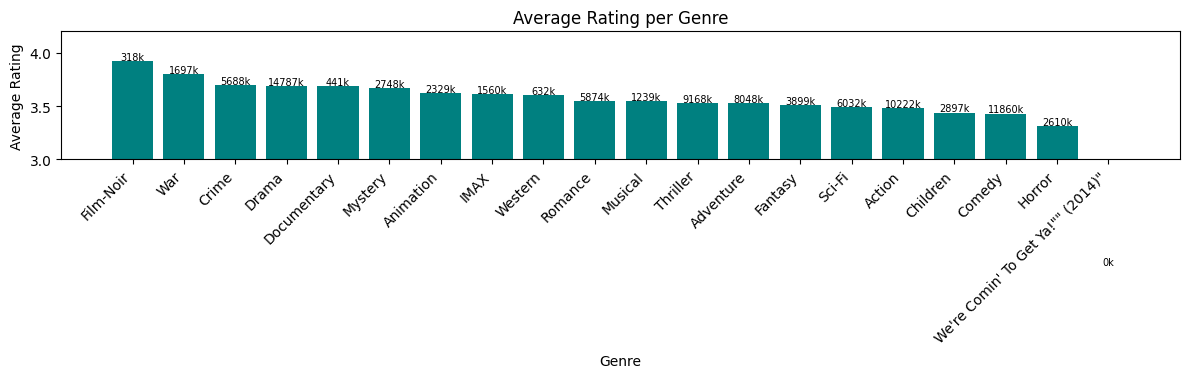

In [46]:
# Explode multi-genre column → count distinct genres, ratings per genre
# 6a — Distinct genres
genres_exploded = (movies_df
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .filter(col("genre") != "(no genres listed)")
)

distinct_genres = genres_exploded.select("genre").distinct().orderBy("genre")
print(f"\n=== Distinct Genres ({distinct_genres.count()} total) ===")
distinct_genres.show(30, truncate=False)

# 6b — Number of movies per genre
movies_per_genre = (genres_exploded
    .groupBy("genre")
    .agg(count("movieId").alias("num_movies"))
    .orderBy(desc("num_movies"))
    .toPandas()
)

plt.figure(figsize=(12, 5))
plt.bar(movies_per_genre["genre"], movies_per_genre["num_movies"], color="darkorange")
plt.xticks(rotation=45, ha="right")
plt.title("Number of Movies per Genre")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# 6c — Average rating per genre (join with ratings)
genre_ratings = (movies_ratings_merged
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .filter(col("genre") != "(no genres listed)")
    .groupBy("genre")
    .agg(
        spark_round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("num_ratings")
    )
    .orderBy(desc("avg_rating"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(genre_ratings["genre"], genre_ratings["avg_rating"], color="teal")
ax.set_ylim(3, 4.2)
ax.set_xlabel("Genre")
ax.set_ylabel("Average Rating")
ax.set_title("Average Rating per Genre")
plt.xticks(rotation=45, ha="right")
for bar, n in zip(bars, genre_ratings["num_ratings"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{n//1000}k", ha="center", fontsize=7)
plt.tight_layout()
plt.show()